# Занятие 03. Glass boxes — демо и конспект

Если у вас не было времени на лекцию — есть ноутбук. Но всё же лучше приходите на лекции! : ) 

Перед каждым фрагментом кода есть такая структура:

- **Блок «Теория»** — что делает метод, формулы и пример;
- **Как устроен код** — тот же код на псевдоязыке, шаг за шагом;
- **На что обращать внимание** — нюансы работы и границы метода.

Части:

1. Линейная регрессия на `sklearn diabetes`: вес и вклад, масштаб, VIF, бутстрап весов, Lasso.
2. EBM на California Housing: кривые признаков, парный член, локальное объяснение.
3. Деревья, лес, бустинг: путь к листу, устойчивость, смещение impurity-важности, три важности XGBoost.

Всё считается на CPU, GPU не необходим.
Окружение — `requirements.txt`.

## Библиотеки здесь

Я буду приводить этот параграф везде, так как в XAI есть некоторая разранненость в смысле `где/что/как` реализовано. По окнчанию курса вы можете не запоминать сноски в тетрадках, а просто использовать ресурс: [XAI Library Navigator](https://xai-table.streamlit.app). 

| Библиотека | Зачем | Почему она |
|---|---|---|
| `scikit-learn` | классические модели линейная регрессия, Lasso, деревья, лес, permutation importance, датасеты | Есть нужные нам атрибуты для интерпретации "glass boxes":`coef_`, `intercept_`, `feature_importances_`, `tree_` |
| `interpret` (InterpretML, Microsoft Research) | Реализация модели EBM (Explainable Boosting Machine) | Реализация EBM от авторов метода (Caruana, Lou, Nori). Модель "прозрачна" по построению: `explain_global()` возвращает кривые всех признаков, `explain_local()` — точное разложение одного прогноза. Интерфейс такой же, как в scikit-learn |
| `xgboost` | градиентный бустинг | одна из самых распространённых реализаций бустинга. Встроенные важности трёх типов (`gain`, `weight`, `cover`). Другие варианты важностей (в catboost, lgbm), вы [можете найти в шпаргалке](https://github.com/SadSabrina/XAI-open_materials/blob/main/PDF/Feature_importance_eng.pdf) |

Датасеты встроены в scikit-learn. 

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes, fetch_california_housing
from sklearn.linear_model import LinearRegression, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
from interpret.glassbox import ExplainableBoostingRegressor
import xgboost as xgb


rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

---
# Часть 1. Линейная регрессия: что значит вес

**Данные.** `sklearn diabetes`: 442 пациента, 10 признаков: возраст, пол, индекс массы тела (`bmi`), среднее давление (`bp`) и шесть показателей крови `s1`–`s6` (`s1` — общий холестерин, `s2` — ЛПНП, `s3` — ЛПВП, `s4` — отношение холестерина к ЛПВП, `s5` — логарифм триглицеридов, `s6` — глюкоза). Цель — количественная мера прогрессии диабета через год. Берём **сырые** признаки (`scaled=False`).

## 1.1. Модель, обучение, вес и вклад

### Блок «Теория»

**Постановка.** Прогноз — взвешенная сумма признаков плюс свободный член:
$$\hat y = \beta_0 + \beta_1 x_1 + \dots + \beta_d x_d.$$

**Обучение (метод наименьших квадратов, МНК).** Ищем веса, при которых сумма квадратов ошибок минимальна:
$$\hat\beta = \arg\min_\beta \sum_{i=1}^n \big(y_i - \hat y_i\big)^2 = (X^\top X)^{-1}X^\top y.$$
Ошибка $y_i - \hat y_i$ называется остатком. Если шум нормальный, МНК совпадает с методом максимального правдоподобия.

**Вес.** $\beta_j = \partial \hat y / \partial x_j$ — на сколько изменится прогноз, если увеличить $x_j$ на единицу, а остальные признаки не менять («при прочих равных»).

**Вклад.** Для одного объекта прогноз раскладывается на слагаемые $\beta_j x_j$. Это **локальное** объяснение: почему у этого объекта такой прогноз. **Глобальное** объяснение описывает модель в среднем по всем объектам.

**Свободный член.** $\beta_0$ — прогноз при всех признаках, равных нулю. Если признаки стандартизованы (из каждого вычли среднее и поделили на стандартное отклонение), ноль — это среднее значение, и $\beta_0$ — прогноз для «среднего» объекта. Без стандартизации $\beta_0$ может быть бессмысленным: пациента с нулевым давлением не бывает.

**Масштаб.** Вес измеряется в «единицах прогноза на единицу признака». Если признаки в разных единицах, веса нельзя сравнивать. После стандартизации вес показывает сдвиг прогноза при изменении признака на одно стандартное отклонение:
$$\beta_j^{\text{std}} = \beta_j \cdot \sigma_j.$$

**Пример важности стандартизации.** 
Цена поездки на такси = 100 ₽ за посадку + 25 ₽ за километр + 10 ₽ за минуту ожидания. 

Здесь 100 — свободный член, 25 и 10 — веса. Поездка на 8 км с 3 минутами ожидания: вклад километров 200 ₽, вклад ожидания 30 ₽, итого 330 ₽. 

Сказать, что километры в 2,5 раза важнее ожидания, нельзя, так как километр и минута — разные единицы. Если считать расстояние в метрах, вес станет 0,025, хотя поездка не изменилась.

### Как устроен код
```
загрузить diabetes в сырых единицах: X (442 × 10), y
модель_сырая ← МНК(X, y)
Xs ← (X − среднее) / σ            # стандартизация каждого столбца
модель_ст ← МНК(Xs, y)
таблица: сырой вес | σ признака | стандартизованный вес
проверка: стандартизованный вес = сырой вес × σ
```

In [2]:
db = load_diabetes(scaled=False, as_frame=True)
X, y = db.data, db.target.values

lr_raw = LinearRegression().fit(X, y)
Xs = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)

lr_std = LinearRegression().fit(Xs, y)
tab = pd.DataFrame({"сырой вес": lr_raw.coef_, "σ признака": X.std(ddof=0).values, "стандартизованный вес": lr_std.coef_}, index=X.columns)
tab["сырой × σ"] = tab["сырой вес"] * tab["σ признака"]
tab.round(2)

,сырой вес,σ признака,стандартизованный вес,сырой × σ
age,-0.04,13.09,-0.48,-0.48
sex,-22.86,0.50,-11.41,-11.41
bmi,5.60,4.41,24.73,24.73
bp,1.12,13.82,15.43,15.43
s1,-1.09,34.57,-37.68,-37.68
s2,0.75,30.38,22.68,22.68
s3,0.37,12.92,4.81,4.81
s4,6.53,1.29,8.42,8.42
s5,68.48,0.52,35.73,35.73
s6,0.28,11.48,3.22,3.22


Что зачем:

- Сырой вес здесь — вес при не стандартизованных признаках (шумная важность). 
- Стандартизированный вес - вес при  стандартизованных признаках (корректная важность). 
- Столбец "сырой вес, умноженный на стандартное отклонение сырого признака" — способ сделать поправку, если по каким-то причинам вам надо, чтобы модель обрабатывала сырые признаки. 

### Как устроен код: вклады одного пациента
```
взять пациента i
вклады ← стандартизованные веса × признаки пациента
прогноз ← β0 + сумма(вкладов)        # совпадает с model.predict
отсортировать вклады по модулю и нарисовать
```

β0 = 152.1;  сумма вкладов = -33.3;  прогноз = 118.9  (model.predict: 118.9);  истина = 63


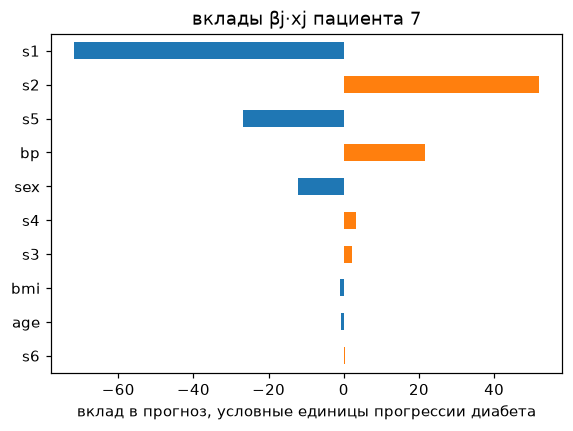

In [3]:
i = 7
contrib = pd.Series(lr_std.coef_ * Xs.iloc[i].values, index=X.columns).sort_values(key=np.abs)
print(f"β0 = {lr_std.intercept_:.1f};  сумма вкладов = {contrib.sum():.1f};  прогноз = {lr_std.intercept_ + contrib.sum():.1f}"
      f"  (model.predict: {lr_std.predict(Xs.iloc[[i]])[0]:.1f});  истина = {y[i]:.0f}")
contrib.plot.barh(color=["tab:orange" if v > 0 else "tab:blue" for v in contrib], figsize=(6, 4), title="вклады βj·xj пациента 7");
plt.xlabel("вклад в прогноз, условные единицы прогрессии диабета");

**В чём измеряется.** Цель `diabetes` — количественная мера прогрессии диабета через год в условных единицах датасета (значения от 25 до 346). Вклад $\beta_j x_j$ и $\beta_0$ измеряются в тех же единицах: «вклад −40» значит, что этот признак уменьшил прогноз на 40 единиц прогрессии относительно среднего пациента.

### На что обращать внимание

- **Знак и величина веса читаются только «при прочих равных».** В данных признаки обычно меняются вместе, поэтому вес — утверждение о модели, а не об объекте. Например, в `diabetes` ИМТ, давление и анализы связаны, поэтому «пациент похудел на σ ИМТ — прогноз упадёт на 24,7» — это утверждение о модели, а не о пациенте.
- **Сравнивайте веса только в одном масштабе.** У `s5` сырой вес около 68, но это логарифм с σ ≈ 0,5. После стандартизации порядок признаков меняется.
- **$\beta_0$ имеет смысл, только если «все признаки равны нулю» что-то значит.** После стандартизации это «средний» объект — здесь средний пациент.
- **Сумма вкладов в точности равна прогнозу.** Это главное свойство линейной модели: локальное объяснение не приближённое.
- **Вес описывает условное среднее,** потому что модель обучена под MSE. Под MAE модель описывала бы медиану.

## 1.2. Мультиколлинеарность и VIF

### Блок «Теория»

**Проблема.** Если признаки сильно связаны, модель знает их общий вклад, но не знает, как его поделить. Пусть рост попал в данные дважды, в сантиметрах ($x_1$) и в дюймах ($x_2 = x_1/2{,}54$). Тогда наборы весов $(0{,}6;\ 0{,}4\cdot2{,}54)$ и $(1{,}2;\ -0{,}2\cdot2{,}54)$ дают одинаковые прогнозы. Веса перестают что-либо значить по отдельности, а маленькое изменение данных сильно их меняет.

**VIF (variance inflation factor).** Для признака $x_j$ обучаем регрессию этого признака на все остальные признаки и берём её $R^2_j$:
$$\mathrm{VIF}_j = \frac{1}{1 - R_j^2}.$$
Если $x_j$ почти полностью выражается через остальные, $R_j^2 \to 1$ и VIF растёт без ограничений. Название объясняется так: дисперсия оценки $\hat\beta_j$ в VIF раз больше, чем если бы $x_j$ не был связан с остальными признаками.

По отбору признаков по VIF существует правило большого пальца: VIF > 10 — сигнал тревоги, VIF > 5 — повод присмотреться, в остальном — не критично.

**Пример.** Пусть двое друзей вместе заплатили за пиццу 1000 ₽. Чек известен, а кто сколько дал — нет: 500 + 500, 900 + 100 и 1200 − 200 одинаково объясняют чек. Модель с двумя почти одинаковыми признаками видит только чек.

### Как устроен код
```
для каждого признака j:
    другие ← все признаки, кроме j
    R²_j ← качество регрессии x_j ~ другие
    VIF_j ← 1 / (1 − R²_j)
вывести корреляцию s1 и s2 и VIF, отсортированные по убыванию
```

In [4]:
def vif(df):
    out = {}
    for c in df.columns:
        others = df.drop(columns=c)
        r2 = LinearRegression().fit(others, df[c]).score(others, df[c])
        out[c] = 1 / (1 - r2)
    return pd.Series(out).round(1).sort_values(ascending=False)
print("corr(s1, s2) =", round(X.s1.corr(X.s2), 2))
vif(X)

corr(s1, s2) = 0.9


s1     59.2
s2     39.2
s3     15.4
s5     10.1
s4      8.9
bmi     1.5
bp      1.5
s6      1.5
sex     1.3
age     1.2
dtype: float64

### На что обращать внимание

- **Высокий VIF — не ошибка модели, а просто индикатор чтения весов.** Веса коррелированных признаков читать по отдельности не стоит.
- **Смотрите на кластер признаков, если он есть, а не на отдельный признак.** Если признаки образуют группу, читайте суммарный вклад группы. В `diabetes` у `s1`–`s5` VIF высокий, потому что `s4` — отношение холестерина к ЛПВП, а `s1` (общий холестерин) почти складывается из ЛПНП (`s2`), ЛПВП (`s3`) и части триглицеридов. Это одна группа «липидов».
- **VIF ловит только линейные связи.** Нелинейная зависимость между признаками может остаться незамеченной.
- **Что делать:** читать суммарный вклад группы, оставить один признак из группы или использовать регуляризацию (раздел 1.4).

## 1.3. Устойчивость веса: бутстрап и |MEAN / STD|

### Блок «Теория»

Базовый способ обнаружить взаимосвязи — бутстрап по данным и оценка весов в такой постановке. Далее везде используем стандартищованную модель. 

**Бутстрап.** Из исходной выборки размера $n$ берём $n$ объектов **с возвращением**: одни попадут дважды, другие ни разу. Обучаем модель на такой выборке и запоминаем веса. Повторяем $B$ раз и получаем $B$ значений каждого веса $\beta_j^{(1)}, \dots, \beta_j^{(B)}$. Разброс этих значений показывает, насколько вес зависит от того, какие именно объекты попали в данные.

**Мера устойчивости.**
$$\text{importance}_j = \left|\frac{\mathrm{MEAN}(\beta_j)}{\mathrm{STD}(\beta_j)}\right|.$$
Это та же идея, что у t-статистики: насколько средний вес отличается от нуля в единицах своего разброса. Если среди весов есть выбросы, используют $|\mathrm{MEDIAN}/\mathrm{IQR}|$ — медиану и межквартильный размах.

**Пример.** Нужно узнать средний рост в школе. Измеряем один класс: 165 см. Но если взять другой класс, может выйти 158, а третий даст 171. Если разные «классы» дают очень разные ответы, одному числу верить нельзя. Бутстрап делает много «других классов» из той же выборки.

### Как устроен код
```
повторить B = 400 раз:
    индексы ← n случайных номеров объектов с возвращением
    веса_b ← МНК(Xs[индексы], y[индексы])
MEAN, STD ← среднее и стандартное отклонение каждого веса по 400 повторам
устойчивость ← |MEAN / STD|
отдельно: корреляция бутстрап-весов s1 и s2
```

In [5]:
B = 400
boot = np.array([LinearRegression().fit(Xs.iloc[ii], y[ii]).coef_
                 for ii in (rng.integers(0, len(y), len(y)) for _ in range(B))])
res = pd.DataFrame({"вес": lr_std.coef_, "MEAN": boot.mean(0), "STD": boot.std(0)}, index=X.columns)
res["|MEAN/STD|"] = (res.MEAN / res.STD).abs()
print("корреляция бутстрап-весов s1 и s2:", round(np.corrcoef(boot[:, 4], boot[:, 5])[0, 1], 2))
res.round(2).sort_values("|MEAN/STD|", ascending=False)

корреляция бутстрап-весов s1 и s2: -0.96


,вес,MEAN,STD,|MEAN/STD|
bmi,24.73,24.76,3.13,7.91
bp,15.43,15.45,3.05,5.06
s5,35.73,36.24,8.13,4.46
sex,-11.41,-11.34,2.90,3.92
s1,-37.68,-37.66,19.72,1.91
s2,22.68,22.66,15.59,1.45
s4,8.42,8.40,7.26,1.16
s6,3.22,2.89,3.01,0.96
s3,4.81,5.00,9.87,0.51
age,-0.48,-0.61,2.72,0.22


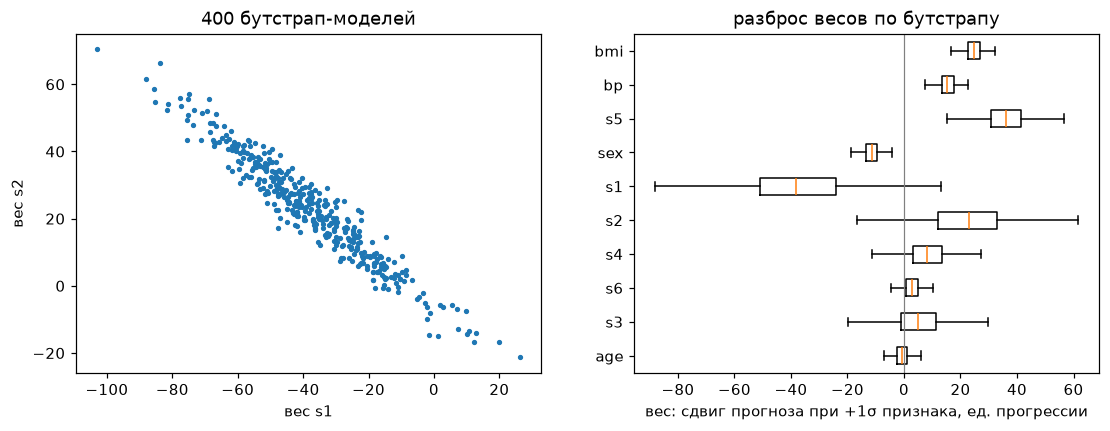

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(boot[:, 4], boot[:, 5], s=6); ax[0].set_xlabel("вес s1"); ax[0].set_ylabel("вес s2"); ax[0].set_title("400 бутстрап-моделей")
order = res["|MEAN/STD|"].sort_values().index
ax[1].boxplot([boot[:, list(X.columns).index(c)] for c in order], orientation="horizontal", tick_labels=list(order), showfliers=False)
ax[1].axvline(0, color="gray", lw=0.8); ax[1].set_title("разброс весов по бутстрапу")
ax[1].set_xlabel("вес: сдвиг прогноза при +1σ признака, ед. прогрессии");

**В чём измеряется.** Вес стандартизованного признака — сдвиг прогноза (в единицах прогрессии диабета) при увеличении признака на одно стандартное отклонение $\sigma_j$. Слева — пары весов `s1` и `s2` из 400 бутстрап-моделей, справа — разброс каждого веса.

### На что обращать внимание

- **Большой вес и надёжный вес — разные вещи.** Самый большой по модулю вес может сильно меняться от выборки к выборке. Здесь у `s1` самый большой по модулю вес, но $|\mathrm{MEAN/STD}| \approx 2$: он меняется почти от −90 до +10. Самый устойчивый признак — ИМТ.
- **Облако бутстрап-весов двух признаков, вытянутое вдоль диагонали, — признак мультиколлинеарности:** когда один вес растёт, другой падает. Здесь так ведут себя `s1` и `s2` — это мультиколлинеарность из 1.2, увиденная иначе.
- **Ящик пересекает ноль — даже знак веса не определён.**
- **Бутстрап проверяет устойчивость к выборке, а не правильность модели.** Устойчивый вес у неверно заданной модели остаётся неверным.

## 1.4. Регуляризация: путь Lasso

Итак, вы не хотим шумные признаки, мы хотим оптимальные. Существует способ отбора признаков на основе регуляризации при помощи $L1$ штрафа. 

### Блок «Теория»

**Ridge (L2)** добавляет к ошибке штраф за сумму квадратов весов, **Lasso (L1)** — за сумму модулей:
$$\text{Ridge: } \min_\beta \sum_i (y_i - \hat y_i)^2 + \lambda \sum_j \beta_j^2, \qquad \text{Lasso: } \min_\beta \sum_i (y_i - \hat y_i)^2 + \lambda \sum_j |\beta_j|.$$

**Почему Lasso обнуляет веса.** Задачу можно переписать так: минимизировать ошибку при ограничении на размер весов. Для Ridge разрешённая область — круг, для Lasso — ромб с углами на осях. Решение — точка, где линия уровня ошибки впервые касается этой области. У ромба касание часто приходится в угол, а в углу один из весов равен нулю. Поэтому Lasso — способ **отбора** признаков, а Ridge только **сжимает** веса.

**Путь Lasso** — как меняются веса при изменении $\lambda$. При очень большом $\lambda$ все веса равны нулю. Если ослаблять штраф, признаки входят в модель по одному. Порядок входа показывает, какие признаки Lasso считает полезными при данном наборе остальных.

**Пример.** У тебя 500 ₽ на обед, и за каждый рубль сверх нужного тебя штрафуют. Ridge — правило «бери всего понемногу»: суп, салат и компот, но порции маленькие. Lasso — правило «бери только самое нужное»: суп и хлеб, а остальное не берёшь совсем. Чем строже штраф, тем меньше позиций в подносе.

### Как устроен код
```
для 200 значений λ от очень большого к маленькому:
    веса(λ) ← решение Lasso на стандартизованных признаках
нарисовать вес каждого признака как функцию log λ
порядок_входа ← признаки, отсортированные по тому, при каком λ их вес впервые стал ≠ 0
```

порядок входа в модель: ['bmi', 's5', 'bp', 's3', 'sex', 's6', 's1', 's4', 's2', 'age']


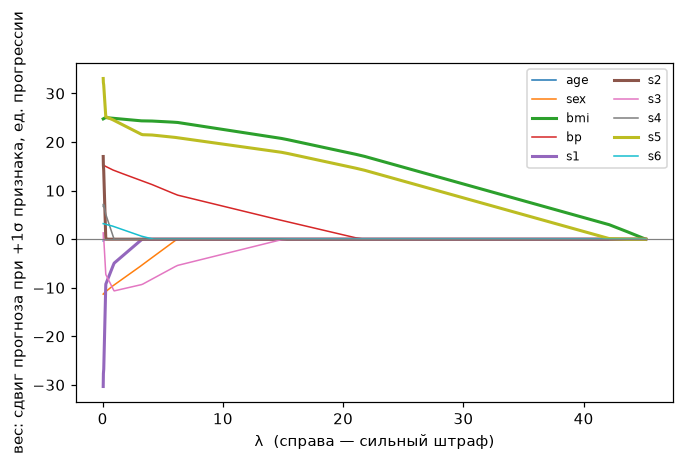

In [7]:
alphas, coefs, _ = lasso_path(Xs.values, y - y.mean(), alphas=200)
fig, ax = plt.subplots(figsize=(7, 4))

for j, f in enumerate(X.columns):
    ax.plot(alphas, coefs[j], label=f, lw=2 if f in ("s1", "s2", "bmi", "s5") else 1)

ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("λ  (справа — сильный штраф)"); 
ax.set_ylabel("вес: сдвиг прогноза при +1σ признака, ед. прогрессии"); 
ax.legend(ncol=2, fontsize=8)
first = {f: np.log10(alphas[np.argmax(np.abs(coefs[j]) > 0)]) for j, f in enumerate(X.columns)}
print("порядок входа в модель:", sorted(first, key=lambda f: -first[f]))

**В чём измеряется.** По оси X $\lambda$, сила штрафа (безразмерная). По оси Y — вес стандартизованного признака в единицах прогрессии диабета на $1\sigma$ признака. Таргет центрирован ($y - \bar y$), поэтому свободного члена нет.

### На что обращать внимание

- **«Lasso выбрал признак» значит «он полезен при этом λ и этих соседях»**, а не «он важен в мире».
- **Из группы коррелированных признаков Lasso часто берёт один, а остальные обнуляет.** Какой из них останется, зависит от данных почти случайно. Здесь `s1` и `s2` входят поздно и с противоположными знаками.
- **Веса Lasso смещены к нулю.** Читать их величину как силу эффекта нельзя; для чтения величины модель переобучают без штрафа на отобранных признаках.
- **Признаки обязательно стандартизовать,** иначе штраф наказывает признаки неравномерно из-за единиц измерения.

---
# Часть 2. EBM на California Housing

**Данные.** 20 640 районов Калифорнии (перепись 1990 года). Признаки: медианный доход (`MedInc`, в десятках тысяч долларов), возраст домов, среднее число комнат и спален, население, среднее число жильцов на дом (`AveOccup`), широта и долгота. Цель — медианная стоимость дома в сотнях тысяч долларов.

## 2.1. От линейной модели к EBM

Итак, мы убедились в линейности, как в сильном способе сохранить модель объяснимой. Не все связи в мире линейны. Вопрос "Можем ли мы что-то с этим сделать?" имеет положительный ответ и описан как класс GLM моделей. 

### Блок «Теория»

**GLM (обобщённая линейная модель).** Линейная связь с признаками должна быть не у самого $y$, а у его преобразования через функцию связи $g$:
$$g\big(E[Y\mid X]\big) = \beta_0 + \sum_j \beta_j x_j.$$
Для регрессии $g(\mu) = \mu$, для классификации — логит $g(\mu) = \log\frac{\mu}{1-\mu}$, для счётчиков — логарифм.

**GAM (обобщённая аддитивная модель).** Вклад признака больше не прямая, а гибкая функция:
$$g\big(E[Y\mid X]\big) = \beta_0 + f_1(x_1) + \dots + f_d(x_d).$$
Вес стал кривой. Прогноз по-прежнему равен сумме вкладов, поэтому каждую кривую можно нарисовать и прочитать отдельно.

**EBM (Explainable Boosting Machine)** — GAM, у которой каждая кривая $f_j$ собрана из тысяч очень мелких деревьев, построенных только по признаку $x_j$. К ней добавлены несколько отобранных пар $f_{jk}(x_j, x_k)$:
$$g\big(E[Y\mid X]\big) = \beta_0 + \sum_j f_j(x_j) + \sum_{(j,k)} f_{jk}(x_j, x_k).$$

**Обучение — циклический бустинг.** В каждом раунде проходим по всем признакам по кругу. Для признака $j$ строим маленькое дерево на остатках, используя только $x_j$, и добавляем его к $f_j$ с очень маленьким шагом $\eta$. Раундов много. Маленький шаг и обход по кругу делают результат почти независимым от порядка признаков и помогают коррелированным признакам делить вклад. Затем алгоритм FAST (Lou et al., KDD 2013) ранжирует пары признаков по полезности, и для лучших пар так же обучаются двумерные функции $f_{jk}$. В конце каждую кривую центрируют: среднее $f_j$ по обучающим данным равно нулю, а общий уровень уходит в $\beta_0$.

**Пример.** Итоговая оценка за четверть = базовые 3 балла + поправка за домашние задания + поправка за контрольные + поправка за посещаемость. Каждая поправка — своя кривая: за первые сданные домашки добавляется много, дальше всё меньше (насыщение). Парный член — особый бонус за сочетание, например «сдал все домашки **и** написал все контрольные». EBM учит такие кривые так: учитель много раз по кругу понемногу подправляет каждую поправку, глядя, где итог ещё расходится с настоящими оценками.

### Как устроен код
```
разделить данные на обучение (75%) и тест (25%)
ebm ← EBM(до 10 парных членов)
ebm.обучить(X_train, y_train):
    f_j ← 0 для всех признаков
    повторить много раундов:
        для каждого признака j по кругу:
            остатки ← y − текущий прогноз
            h ← мелкое дерево по одному x_j на остатках
            f_j ← f_j + η · h
    FAST отбирает лучшие пары (j, k), для них так же обучается f_jk
вывести список членов модели: 8 кривых + отобранные пары
```

#### Подробнее: как поставлен бустинг в EBM

В `interpret` 0.7.8 (который стоит в окружении курса).

**Задача.** Модель ищется в аддитивном виде
$$F(x) = \beta_0 + \sum_j f_j(x_j) + \sum_{(j,k)} f_{jk}(x_j, x_k)$$
и минимизирует суммарную потерю на обучении $\sum_i L\big(y_i, F(x_i)\big)$. Для регрессии по умолчанию $L(y, F) = \tfrac12 (y - F)^2$ (`objective="rmse"`).

**Бинаризация.** Перед обучением каждый признак разбивается на не более чем 1024 бина по квантилям (`max_bins`), для пар — на 64 бина (`max_interaction_bins`). Поэтому $f_j$ — задает одно число на бин. Отсюда ступенчатые кривые.

**Инициализация.** $f_j \equiv 0$ для всех признаков, $\beta_0$ — среднее $y$ на обучении.

**Один шаг бустинга по признаку $j$.**
1. Псевдо-остатки — антиградиент потери по текущему прогнозу:
$$r_i = -\frac{\partial L(y_i, F)}{\partial F}\Big|_{F = F(x_i)},$$
для квадратичной потери это обычный остаток $r_i = y_i - F(x_i)$.
2. По остаткам строится дерево $h$, которое видит **только признак $x_j$** и имеет не больше двух листьев (`max_leaves=2`, то есть одно разбиение) и не меньше 4 объектов в листе:
$$h = \arg\min_{h \in \mathcal H_j} \sum_i \big(r_i - h(x_{ij})\big)^2.$$
3. Кривая сдвигается на маленький шаг $\eta = 0{,}04$ (`learning_rate`):
$$f_j \leftarrow f_j + \eta\, h, \qquad F(x) \leftarrow F(x) + \eta\, h(x_j).$$

Это градиентный бустинг, как в разделе 3.4, но каждое дерево ограничено одним признаком. Поэтому сумма всех деревьев по признаку $j$ и есть кривая $f_j$.

**Порядок шагов.** Раунд — по одному шагу на каждый член модели, по кругу (циклический бустинг). Первые 500 раундов (`smoothing_rounds`) сильно регуляризованы и задают общую форму кривых. В версии 0.7 к циклическим шагам добавляются жадные: шаг делается по тому члену, который сильнее всего уменьшает потерю; жадных шагов до 10 раз больше, чем циклических (`greedy_ratio=10`).

**Остановка.** 15% обучающих данных откладываются на валидацию (`validation_size=0.15`). Обучение останавливается, если 100 раундов подряд потеря на валидации не улучшается (`early_stopping_rounds`), но не позже чем через 50 000 раундов (`max_rounds`).

**Бэггинг.** Всё обучение повторяется на 14 разных разбиениях на обучение и валидацию (`outer_bags=14`), итоговые кривые — среднее по 14 моделям. Разброс между ними даёт полосы неопределённости на графиках.

**Пары.** Когда одномерные кривые обучены, алгоритм FAST оценивает, насколько каждая пара признаков могла бы уменьшить остаточную ошибку, и берёт лучшие (у нас `interactions=10`; по умолчанию — 5 × число признаков). Для выбранных пар тем же бустингом обучаются двумерные таблицы $f_{jk}$ на остатках, с деревьями по двум признакам.

**Центрирование.** В конце каждый член модели — и кривые, и парные таблицы — сдвигают так, чтобы его среднее по обучающим данным было нулём, а сдвиг переносят в $\beta_0$. Поэтому вклад читается относительно среднего. Пары обучаются на остатках после одномерных кривых, поэтому $f_{jk}$ описывает в основном то, что кривые не объяснили. Полной «очистки» пар от одномерной части (purification) по умолчанию в версии 0.7 нет.

**Про то, почему указаны версии.**  Всё просто — библиотеки XAI тоже обновляются и иногда добавляют/убирают что-либо. Полезно смотреть исходники. 


In [8]:
ch = fetch_california_housing(as_frame=True)
Xc, yc = ch.data, ch.target.values
Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.25, random_state=0)
ebm = ExplainableBoostingRegressor(interactions=10, random_state=0, n_jobs=-1).fit(Xtr, ytr)
print("члены модели:", ebm.term_names_)

члены модели: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedInc & HouseAge', 'MedInc & AveOccup', 'MedInc & Longitude', 'HouseAge & AveOccup', 'AveRooms & AveOccup', 'AveBedrms & Longitude', 'Population & AveOccup', 'AveOccup & Latitude', 'AveOccup & Longitude', 'Latitude & Longitude']


## 2.2. Кривые признаков

### Как устроен код
```
global ← ebm.explain_global()
для признаков MedInc, AveOccup, HouseAge:
    границы бинов и значения f_j ← global.data(номер члена)
    нарисовать ступенчатую кривую f_j(x_j)
```

(1.0, 6.0)

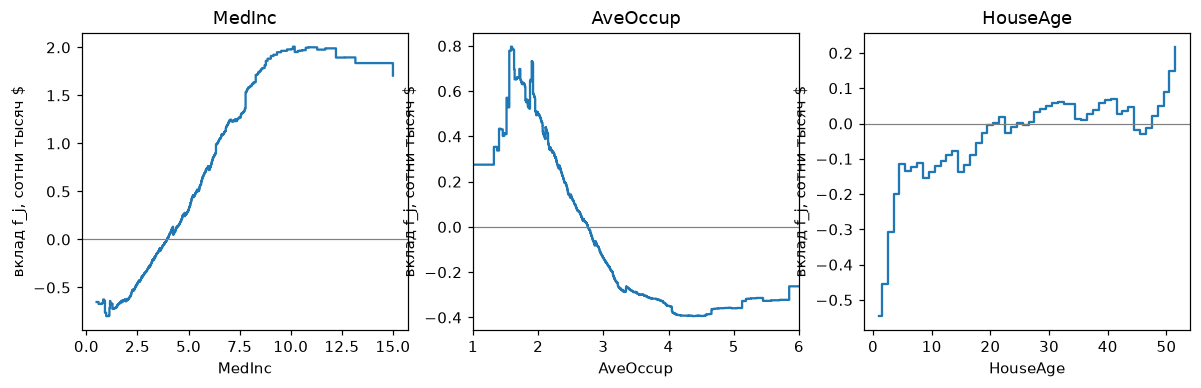

In [9]:
gl = ebm.explain_global()
fig, axs = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, name in zip(axs, ["MedInc", "AveOccup", "HouseAge"]):
    d = gl.data(list(ebm.term_names_).index(name))
    edges = np.array(d["names"], dtype=float); sc = np.array(d["scores"])
    ax.step(edges[:-1], sc, where="post"); ax.axhline(0, color="gray", lw=0.8); ax.set_title(name)
    ax.set_ylabel("вклад f_j, сотни тысяч $"); ax.set_xlabel(name)
axs[1].set_xlim(1, 6)

**В чём измеряется.** Цель California Housing — медианная стоимость дома в районе в **сотнях тысяч долларов** (2,0 = $200 000). Вклад $f_j(x_j)$ — в тех же единицах: «+0,5» значит, что при таком значении признака прогноз на 50 тысяч долларов выше, чем у района со средним вкладом этого признака. По оси X — значение признака в его собственных единицах: `MedInc` — медианный доход в десятках тысяч долларов в год, `AveOccup` — среднее число жильцов на дом, `HouseAge` — медианный возраст домов в годах.

**На наших данных:** доход — почти линейный рост, затем насыщение; жильцов на дом — пик около 1,5–2, дальше вклад отрицательный; возраст домов — старые районы немного дороже.

### На что обращать внимание

- **Кривая читается как вес, только вес теперь зависит от значения признака.** Там, где кривая выше нуля, признак толкает прогноз вверх относительно среднего объекта. Ноль — средний вклад, потому что кривые центрированы.
- **Рваная кривая с острыми зубцами** — признак переобучения на редких значениях. Смотрите, сколько объектов в этой области признака.
- **Края признака (или зоны его малой концентрации) ненадёжны:** там мало данных, и кривая держится на нескольких объектах.
- **Форма кривой зависит от коррелированных соседей в модели.** Если удалить признак, часть его вклада перейдёт к коррелированным с ним. Здесь, например, если удалить широту, её вклад частично заберут другие признаки, связанные с расположением.
- **Кривая описывает модель, а не причину.** Здесь старые районы немного дороже, но возраст домов связан с расположением: старые районы — это часто центры старых городов на побережье.

## 2.3. Парный член: широта × долгота

### Блок «Теория»

Парный член $f_{jk}(x_j, x_k)$ — двумерная поправка к сумме одномерных кривых. Он описывает только то, чего не объясняют $f_j$ и $f_k$ по отдельности. Сумма $f_{\text{Lat}} + f_{\text{Lon}}$ может сказать «южнее — дороже» и «западнее — дороже», но не «дорого именно у побережья залива и Лос-Анджелеса». Это делает пара.

**Пример.** Мороженое продаётся лучше летом и лучше в выходные. Но летние выходные дают больше, чем «лето» плюс «выходные» по отдельности: на пляже очереди. Эта добавка и есть парный член.

### Как устроен код
```
найти член с Latitude и Longitude
значения ← двумерная таблица поправок на сетке бинов широты и долготы
нарисовать её как карту: красное — дороже суммы кривых, синее — дешевле
```

Text(0.5, 1.0, 'Latitude & Longitude')

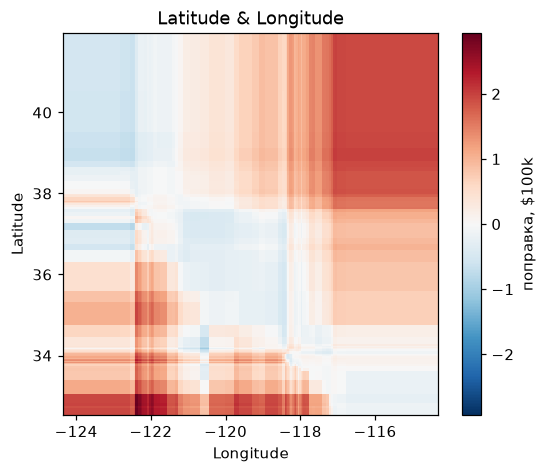

In [10]:
pair = [t for t in ebm.term_names_ if "Latitude" in t and "Longitude" in t][0]
d = gl.data(list(ebm.term_names_).index(pair))
sc = np.array(d["scores"]); le = np.array(d["left_names"], dtype=float); ri = np.array(d["right_names"], dtype=float)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
lim = np.abs(sc).max()
m = ax.pcolormesh(ri, le, sc, cmap="RdBu_r", vmin=-lim, vmax=lim) if pair.startswith("Latitude") else ax.pcolormesh(le, ri, sc.T, cmap="RdBu_r", vmin=-lim, vmax=lim)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); fig.colorbar(m, label="поправка, $100k"); ax.set_title(pair)

**В чём измеряется.** Цвет — значение $f_{\text{Lat}\times\text{Lon}}$ в сотнях тысяч долларов: на сколько прогноз в этой точке выше (красное) или ниже (синее) суммы одномерных прогнозов в этих точках кривых широты и долготы. Оси — широта и долгота в градусах.

**Пример.** Пусть в модели всего два признака, широта и долгота, и три члена. Тогда прогноз
$$\hat y = \beta_0 + f_{\text{Lat}}(x_{\text{Lat}}) + f_{\text{Lon}}(x_{\text{Lon}}) + f_{\text{Lat}\times\text{Lon}}(x_{\text{Lat}}, x_{\text{Lon}}).$$

Подставим значения членов из обученной модели для двух районов (в сотнях тысяч долларов, $\beta_0 = 2{,}07$):

| Район | $f_{\text{Lat}}$ | $f_{\text{Lon}}$ | $\beta_0 + f_{\text{Lat}} + f_{\text{Lon}}$ | $f_{\text{Lat}\times\text{Lon}}$ | $\hat y$ |
|---|---|---|---|---|---|
| Сан-Франциско (37,77; −122,42) | −0,92 | +1,88 | 3,03 | **+0,36** | 3,40 |
| Фресно (36,75; −119,76) | −0,74 | −0,02 | 1,32 | **−0,17** | 1,15 |

Без парного члена модель умеет сказать только «севернее — дешевле» и «западнее — дороже», и эти два эффекта складываются одинаково для любой точки. Парный член добавляет поправку, которая зависит от сочетания координат: у побережья залива Сан-Франциско район на 36 тысяч долларов дороже, чем дала бы сумма кривых, а во Фресно, в центральной долине, — на 17 тысяч дешевле.


### На что обращать внимание

- **Парный член — поправка, а не полный эффект пары признаков.** Полный эффект — сумма двух кривых и пары; здесь это $f_{\text{Lat}} + f_{\text{Lon}} + f_{\text{Lat}\times\text{Lon}}$.
- **Пар немного, и они отобраны автоматически.** Если важная пара не попала в модель, её эффект размазан по одномерным кривым. Тройные взаимодействия EBM не видит вовсе.
- **В областях без данных значения карты ничего не значат.** В нашем примере это океан и пустыня.

## 2.4. Локальное объяснение одного района

### Блок «Теория»

Для одного объекта прогноз EBM **в точности** равен
$$\hat y = \beta_0 + \sum_j f_j(x_j) + \sum_{(j,k)} f_{jk}(x_j, x_k).$$
Каждое слагаемое — вклад признака или пары в этот прогноз. В отличие от post-hoc методов (LIME, SHAP — занятие 05), здесь ничего не приближается: объяснение и есть вычисление модели.

### Как устроен код
```
прогнозы ← ebm.predict(X_test)
i ← первый район с прогнозом, близким к истине, и ценой 1,8–3,2
local ← ebm.explain_local(район i)
вклады ← значения всех членов модели для района i
проверка: β0 + сумма(вкладов) = прогноз
```

In [11]:
pe = ebm.predict(Xte)
i = int(np.where((np.abs(pe - yte) < 0.08) & (yte > 1.8) & (yte < 3.2))[0][0])
loc = ebm.explain_local(Xte.iloc[[i]], yte[[i]]).data(0)
contrib = pd.Series(loc["scores"], index=loc["names"]).sort_values(key=np.abs, ascending=False)
print(f"прогноз {pe[i]:.3f} = β0 {ebm.intercept_:.3f} + сумма вкладов {contrib.sum():.3f};  истина {yte[i]:.2f}")
print(Xte.iloc[i].round(2).to_dict())
contrib.head(8).round(3)

прогноз 2.205 = β0 2.074 + сумма вкладов 0.131;  истина 2.20
{'MedInc': 4.48, 'HouseAge': 33.0, 'AveRooms': 6.22, 'AveBedrms': 1.04, 'Population': 421.0, 'AveOccup': 3.05, 'Latitude': 34.15, 'Longitude': -117.94}


Latitude               0.861
Longitude             -0.714
AveOccup              -0.160
MedInc                 0.140
MedInc & HouseAge     -0.064
HouseAge               0.055
AveRooms & AveOccup    0.053
MedInc & Longitude    -0.051
dtype: float64

**В чём измеряется.** Все вклады, $\beta_0$ и прогноз — в сотнях тысяч долларов. $\beta_0 \approx 2{,}07$ — средняя стоимость по обучающей выборке ($207 000).

### На что обращать внимание

- **Сумма вкладов плюс $\beta_0$ равна прогнозу** — проверено в выводе выше.
- **Большие вклады с разными знаками могут гасить друг друга.** По отдельности это сильные эффекты, вместе — небольшой. У этого района широта даёт около +0,86, долгота около −0,72.
- **Вклад — относительно среднего объекта,** потому что кривые центрированы. «Вклад −0,15» значит «на 15 тысяч дешевле среднего по этому признаку», а не «признак отнимает 15 тысяч от нуля».
- **Вклад — свойство модели.** Вопрос «что будет, если в районе поднимется доход» — каузальный (раздел 02 занятия), и кривая на него не отвечает.

---
# Часть 3. Деревья, лес, бустинг

## 3.1. Дерево решений и путь к листу

### Блок «Теория»

**Постановка.** Дерево делит пространство признаков на прямоугольные области $R_\ell$, по одной на лист. В каждом внутреннем узле проверяется условие $x_j \le t$, объект уходит налево или направо, в листе стоит прогноз $c_\ell$: среднее для регрессии, частый класс для классификации.
$$a(x) = \sum_\ell c_\ell \cdot \mathbb 1[x \in R_\ell].$$

**Обучение — жадное.** В узле $N$ перебираются все признаки и все пороги и выбирается разбиение с наибольшим снижением загрязнённости (impurity):
$$\Delta = I(N) - \frac{n_L}{n} I(L) - \frac{n_R}{n} I(R).$$
Для регрессии $I$ — дисперсия ответов в узле, для классификации — индекс Джини $1 - \sum_k p_k^2$ или энтропия $-\sum_k p_k \log p_k$. Затем то же самое повторяется в детях, пока не сработает условие остановки: максимальная глубина, минимум объектов в листе.

**Объяснение одного прогноза** — конъюнкция условий на пути от корня к листу. Оно точное, но его длина равна глубине.

**Пример.** Игра «угадай животное за несколько вопросов»: «Оно летает?» — «Нет». «У него есть полоски?» — «Да». «Зебра». Каждый вопрос делит варианты на две группы, и хороший первый вопрос отсекает как можно больше. Дерево выбирает вопросы так же — жадно, сначала самый полезный. Ответ «зебра, потому что не летает и полосатая» — это путь к листу.

### Как устроен код
```
дерево ← DecisionTree(глубина 2) на двух признаках: долгота, широта
в каждом узле: перебрать пороги по обоим признакам, взять максимум Δ
напечатать дерево как набор правил «если … то …»
```

In [12]:
t2 = DecisionTreeRegressor(max_depth=2, random_state=0).fit(Xtr[["Longitude", "Latitude"]], ytr)
print(export_text(t2, feature_names=["Longitude", "Latitude"]))

|--- Latitude <= 37.94
|   |--- Longitude <= -121.87
|   |   |--- value: [2.90]
|   |--- Longitude >  -121.87
|   |   |--- value: [2.05]
|--- Latitude >  37.94
|   |--- Latitude <= 38.86
|   |   |--- value: [1.60]
|   |--- Latitude >  38.86
|   |   |--- value: [1.02]



**В чём измеряется.** `value` в листьях — средняя стоимость домов районов, попавших в лист, в сотнях тысяч долларов. Пороги — в градусах широты и долготы.

**На наших данных:** дерево само нашло географию — север штата дешевле (1,02 и 1,60), побережье залива Сан-Франциско (западнее −121,87°) дороже всего (2,90).

### На что обращать внимание

- **Объяснение прогноза — ровно те условия, по которым модель приняла решение.** Например, для района в Сакраменто (широта 38,6): «широта > 37,94 и ≤ 38,86 → 1,60».
- **Глубина = длина объяснения.** Дерево глубины 2 читается целиком, но точность у него низкая. Дерево глубины 20 точнее, но его путь — 20 условий.
- **Разрезы только вдоль осей.** Диагональную границу дерево строит лесенкой, а взаимодействие вида XOR в корне вообще не видит: разбиение по любому признаку даёт $\Delta = 0$.

## 3.2. Лес: усреднение гасит дисперсию

### Блок «Теория»

**Случайный лес** (Breiman, 2001) обучает $M$ деревьев, каждое на своей бутстрап-выборке и со случайным подмножеством признаков в каждом узле, и усредняет их прогнозы:
$$a(x) = \frac{1}{M}\sum_{m=1}^M a_m(x).$$

**Почему это работает.** Пусть у каждого дерева дисперсия прогноза $\sigma^2$, а попарная корреляция деревьев $\rho$. Тогда дисперсия среднего
$$\mathrm{Var} = \rho\sigma^2 + \frac{1-\rho}{M}\sigma^2.$$
С ростом $M$ второе слагаемое исчезает, первое остаётся. Поэтому деревья делают непохожими: случайные подмножества признаков уменьшают $\rho$. Смещение при усреднении почти не меняется.

**Пример.** Угадываешь число конфет в банке. Один человек ошибается сильно. Средний ответ всего класса обычно гораздо ближе к правде — но только если одноклассники не списывали друг у друга. Списывание — это корреляция $\rho$: тогда усреднение почти не помогает.

### Как устроен код
```
повторить 30 раз:
    выборка ← бутстрап из 2000 районов обучения
    одно_дерево ← глубокое дерево на выборке; запомнить прогнозы на 300 тестовых районах
    лес ← 100 деревьев на выборке; запомнить прогнозы на тех же районах
для каждого района: std прогноза по 30 повторам — для дерева и для леса
сравнить средние std
```

средний разброс прогноза: дерево 0.55, лес 0.15  ($100k)


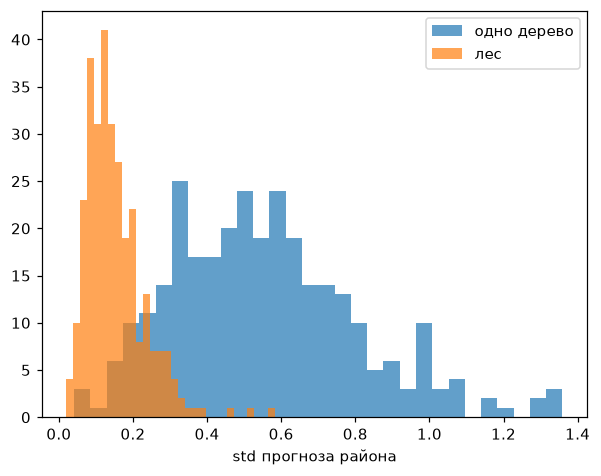

In [13]:
small, ysmall, probe = Xtr.iloc[:2000], ytr[:2000], Xte.iloc[:300]
pt, pf = [], []
for b in range(30):
    ii = rng.integers(0, len(small), len(small))
    pt.append(DecisionTreeRegressor(random_state=b).fit(small.iloc[ii], ysmall[ii]).predict(probe))
    pf.append(RandomForestRegressor(n_estimators=100, random_state=b, n_jobs=-1).fit(small.iloc[ii], ysmall[ii]).predict(probe))
st_t, st_f = np.array(pt).std(0), np.array(pf).std(0)
print(f"средний разброс прогноза: дерево {st_t.mean():.2f}, лес {st_f.mean():.2f}  ($100k)")
plt.hist(st_t, bins=30, alpha=0.7, label="одно дерево"); plt.hist(st_f, bins=30, alpha=0.7, label="лес"); plt.legend(); plt.xlabel("std прогноза района");

**В чём измеряется.** Разброс (стандартное отклонение) прогноза одного района по 30 бутстрап-моделям, в сотнях тысяч долларов: 0,55 значит, что прогноз одного дерева «гуляет» примерно на ±55 тысяч долларов в зависимости от выборки.

### На что обращать внимание

- **Лес устойчивее дерева, но одного читаемого дерева больше нет:** объяснение прогноза — это 100 путей. Здесь разброс прогноза у леса в 3,7 раза меньше, чем у дерева (0,15 против 0,55).
- **Важности леса — среднее важностей деревьев.** Усреднение уменьшает их разброс, но не исправляет систематическое смещение метрики (следующий раздел).

## 3.3. Смещение impurity-важности

### Блок «Теория»

**Impurity-важность** (`feature_importances_` в scikit-learn) — суммарное снижение загрязнённости во всех узлах, где использован признак, взвешенное долей объектов в узле и нормированное так, чтобы сумма по признакам была 1:
$$\mathrm{Imp}(j) \propto \sum_{\text{узлы } N \text{ по } j} \big[w_N I(N) - w_L I(L) - w_R I(R)\big].$$

Знак $\propto$ читается «пропорционально»: левая часть равна правой с точностью до постоянного множителя. Здесь этот множитель — нормировка: после неё сумма важностей по всем признакам равна 1.
Она считается **на обучающих данных** и отвечает на вопрос «насколько признак помог подогнаться под обучение».

**Почему она смещена** (Strobl et al., BMC Bioinformatics, 2007). У непрерывного признака тысячи возможных порогов, у категории с 50 значениями — огромное число разбиений, у бинарного признака — одно. Чем больше кандидатов, тем выше шанс, что какой-то из них **случайно** снизит загрязнённость на обучении. Поэтому «богатые» признаки получают важность, даже если с целью не связаны.

**Permutation importance** (подробно — занятие 04): перемешиваем значения одного признака в тестовых данных и смотрим, насколько упало качество. Если признак модели не нужен, перемешивание ничего не меняет.

**Пример.** Лотерея: у одного ученика 1000 билетов, у другого один. Даже если билеты пустые и выигрыш случаен, у первого гораздо больше шансов «выиграть». Непрерывный признак — ученик с тысячей билетов.

### Как устроен код
```
к данным добавить 3 признака-пустышки:
    random_num    ← нормальный шум (тысячи порогов)
    random_cat_50 ← случайная категория из 50 значений
    random_cat_2  ← случайная монетка (один порог)
лес ← обучить на train с пустышками
impurity ← лес.feature_importances_                    # по обучению
permutation ← для каждого признака: перемешать его в test, падение R²
сравнить две колонки
```

In [14]:
Xn, Xn_te = Xtr.copy(), Xte.copy()
for D in (Xn, Xn_te):
    D["random_num"] = rng.normal(0, 1, len(D))
    D["random_cat_50"] = rng.integers(0, 50, len(D))
    D["random_cat_2"] = rng.integers(0, 2, len(D))
rf = RandomForestRegressor(n_estimators=150, random_state=0, n_jobs=-1).fit(Xn, ytr)
pi = permutation_importance(rf, Xn_te, yte, n_repeats=8, random_state=0, n_jobs=-1)
pd.DataFrame({"impurity (train)": rf.feature_importances_, "permutation (test)": pi.importances_mean}, index=Xn.columns).round(4).sort_values("impurity (train)", ascending=False)

,impurity (train),permutation (test)
MedInc,0.5265,0.8036
AveOccup,0.1318,0.1980
Latitude,0.0787,0.3812
Longitude,0.0784,0.2855
HouseAge,0.0539,0.0703
AveRooms,0.0436,0.0289
Population,0.0273,0.0079
AveBedrms,0.0267,0.0084
random_num,0.0161,-0.0005
random_cat_50,0.0148,0.0010


**В чём измеряется.** Impurity-важность — доля суммарного снижения загрязнённости (дисперсии цели) на обучении, нормированная так, что сумма по всем признакам равна 1; безразмерна. Permutation importance — падение $R^2$ на тесте после перемешивания признака; тоже безразмерна. Отрицательное значение около нуля значит, что после перемешивания качество случайно чуть выросло: признак не нужен.

### На что обращать внимание

- **Ненулевая impurity-важность не доказывает, что признак полезен.** У признаков с большим числом возможных порогов выше шанс случайно получить важность. Здесь пустышки `random_num` и `random_cat_50` получили ненулевую impurity-важность, бинарная `random_cat_2` — почти ноль, а permutation importance у всех трёх около нуля. Сравнивайте с пустышкой: признак важнее случайного шума?
- **Impurity-важность ничего не говорит о новых данных.** Для этого нужна важность на отложенной выборке.
- **Коррелированные признаки делят impurity-важность произвольно:** дерево выбирает один из двух почти одинаковых признаков и отдаёт ему всё.

## 3.4. Бустинг и три важности XGBoost

### Блок «Теория»

**Градиентный бустинг** (Friedman, 2001) строит деревья по очереди. Начинаем с константы $F_0$ (среднего $y$). На шаге $m$ считаем, куда сдвинуть прогноз каждого объекта, чтобы лосс уменьшился, — антиградиент:
$$r_i = -\frac{\partial L(y_i, F)}{\partial F}\Big|_{F = F_{m-1}(x_i)}.$$
Для MSE это обычный остаток $y_i - F_{m-1}(x_i)$. Новое неглубокое дерево $h_m$ учится предсказывать $r_i$ и добавляется с маленьким шагом $\nu$:
$$F_M(x) = F_0 + \sum_{m=1}^M \nu\, h_m(x).$$
Это градиентный спуск, только шаги делаются не по параметрам, а по функции. Лес борется с дисперсией, бустинг — со смещением.

**Три встроенные важности XGBoost:**
- **weight** — сколько раз признак использован в разбиениях;
- **gain** — насколько в среднем его разбиения снизили лосс (Chen & Guestrin, KDD 2016):
$$\mathrm{Gain} = \tfrac12\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma,$$
где $G$ — сумма первых производных лосса в листе, $H$ — сумма вторых, $\lambda$ и $\gamma$ — регуляризация;
- **cover** — сколько объектов задели разбиения по признаку. Каждый объект считается с весом, равным второй производной лосса: для MSE это 1, для log-loss $p(1-p)$, то есть уверенные объекты почти не считаются.

**Пример.** Класс пишет сочинение по цепочке. Первый пишет черновик, второй исправляет его ошибки, третий — то, что осталось после второго, и так далее. Каждый делает небольшую правку. Вклад ученика можно мерить по-разному: сколько раз он брал ручку (weight), насколько его правки улучшили текст (gain), сколько предложений он затронул (cover). Ответы не обязаны совпадать.

### Как устроен код
```
модель ← XGBoost(400 деревьев глубины 5, шаг 0,08) на train с пустышками
для типа в (gain, weight, cover):
    важность[тип] ← booster.get_score(тип)
нормировать каждую колонку к сумме 1, сравнить
ранговая корреляция Спирмена между рейтингами признаков
```

In [15]:
xg = xgb.XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.08, random_state=0, n_jobs=4).fit(Xn, ytr)
bst = xg.get_booster()
imp = pd.DataFrame({k: pd.Series(bst.get_score(importance_type=k)) for k in ("gain", "weight", "cover")}).fillna(0)
(imp / imp.sum()).round(3).sort_values("gain", ascending=False)

,gain,weight,cover
MedInc,0.500,0.138,0.134
AveOccup,0.136,0.118,0.087
Longitude,0.094,0.148,0.146
Latitude,0.080,0.165,0.141
HouseAge,0.071,0.084,0.081
AveRooms,0.041,0.089,0.152
AveBedrms,0.022,0.078,0.081
Population,0.018,0.083,0.062
random_cat_2,0.015,0.004,0.030
random_num,0.012,0.051,0.044


**В чём измеряется.** Каждая колонка нормирована к сумме 1 по признакам, поэтому числа — доли. До нормировки: `gain` — среднее снижение функции потерь (для MSE — квадрат сотен тысяч долларов) на одно разбиение, `weight` — число разбиений, `cover` — среднее число объектов в разбиении (с весом по второй производной лосса; для MSE это просто число объектов).

In [16]:
print("Спирмен gain vs weight:", round(spearmanr(imp.gain, imp.weight).correlation, 2))
print("Спирмен gain vs cover: ", round(spearmanr(imp.gain, imp.cover).correlation, 2))

Спирмен gain vs weight: 0.87
Спирмен gain vs cover:  0.75


### На что обращать внимание

- **Три важности одной модели могут давать разные рейтинги.** Здесь широта и долгота по `weight` обгоняют `AveOccup`, по `gain` — нет.
- **Признак может часто использоваться в слабых разбиениях:** высокий `weight` и `cover` при низком `gain`. Здесь так ведут себя пустышки: модель использует их в разбиениях, которые почти ничего не дают.
- **`gain` ближе всего к вопросу «помогает ли признак», но тоже считается на обучении** и наследует смещение к признакам с большим числом порогов.
- **«Важный признак» не определён, пока не сказано, какая важность.** В отчёте всегда указывайте тип важности и данные, на которых она посчитана.
- **В CatBoost свои важности:** `PredictionValuesChange` (насколько разбиения меняют прогноз; сумма по признакам — 100) и `LossFunctionChange` (насколько вырастет лосс без признака; может быть отрицательной — тогда без признака модель лучше).

---
## Итог

| Модель | Объяснение по построению | Главная ловушка |
|---|---|---|
| Линейная регрессия | веса $\beta_j$ и вклады $\beta_j x_j$ | масштаб, мультиколлинеарность, вес ≠ причинный эффект |
| Lasso | какие признаки отобраны | из коррелированных берёт один почти случайно |
| EBM | кривые $f_j$, пары $f_{jk}$, точное разложение прогноза | корреляции, только парные взаимодействия, края признаков |
| Дерево | путь к листу | глубина, разрезы вдоль осей, неустойчивость |
| Лес, бустинг | встроенные важности | смещение к «богатым» признакам, считаются на обучении, типы важности не совпадают |

На занятии 04 — permutation importance, PDP, ICE и ALE: объяснения модели, которую нельзя переделать.